# 🎵 Amazon Music Clustering
### Unsupervised Machine Learning — Audio Feature Clustering
---
**Goal:** Automatically group songs by audio characteristics using K-Means, DBSCAN, and Hierarchical Clustering.

## 0. Setup & Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples, davies_bouldin_score
from scipy.cluster.hierarchy import dendrogram, linkage

import os
os.makedirs('outputs', exist_ok=True)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded ✓')

Libraries loaded ✓


## 1. Load & Explore Data

In [3]:
df = pd.read_csv('single_genre_artists.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (10250, 23)


,id_songs,name_song,popularity_songs,duration_ms,explicit,id_artists,release_date,danceability,energy,key,...,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,genres,name_artists,popularity_artists
0,0IA0Hju8CAgYfV1hwhidBH,La Java,0.0,161427.0,0.0,4AxgXfD7ISvJSTObqm4aIE,1922,0.563,0.184,4.0,...,0.993,0.000016,0.325,0.654,133.088,3.0,5078.0,['vintage chanson'],Mistinguett,22.0
1,1b8HZQCqcqwbzlA1jRTp6E,En Douce,0.0,223440.0,0.0,4AxgXfD7ISvJSTObqm4aIE,1922,0.427,0.180,10.0,...,0.989,0.000000,0.128,0.431,78.459,3.0,5078.0,['vintage chanson'],Mistinguett,22.0
2,5d5gQxHwYovxR5pqETOIAa,J'en Ai Marre,0.0,208267.0,0.0,4AxgXfD7ISvJSTObqm4aIE,1922,0.511,0.206,0.0,...,0.995,0.000000,0.418,0.481,70.443,4.0,5078.0,['vintage chanson'],Mistinguett,22.0
3,1EO65UEEPfy7CR0NK2sDxy,Ils n'ont pas ca,0.0,161933.0,0.0,4AxgXfD7ISvJSTObqm4aIE,1924,0.676,0.467,9.0,...,0.991,0.000000,0.219,0.726,129.775,4.0,5078.0,['vintage chanson'],Mistinguett,22.0
4,6a58gXSgqbIsXUhVZ6ZJqe,La belote,0.0,167973.0,0.0,4AxgXfD7ISvJSTObqm4aIE,1924,0.650,0.298,9.0,...,0.991,0.000000,0.373,0.844,75.950,4.0,5078.0,['vintage chanson'],Mistinguett,22.0


In [4]:
print('Data Types:')
print(df.dtypes)
print('\nMissing Values:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Data Types:
id_songs               object
name_song              object
popularity_songs      float64
duration_ms           float64
explicit              float64
id_artists             object
release_date           object
danceability          float64
energy                float64
key                   float64
loudness              float64
mode                  float64
speechiness           float64
acousticness          float64
instrumentalness      float64
liveness              float64
valence               float64
tempo                 float64
time_signature        float64
followers             float64
genres                 object
name_artists           object
popularity_artists    float64
dtype: object

Missing Values:
id_songs              0
name_song             1
popularity_songs      1
duration_ms           1
explicit              1
id_artists            1
release_date          1
danceability          1
energy                1
key                   1
loudness              1
mod

In [5]:
df.describe().round(3)

,popularity_songs,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,followers,popularity_artists
count,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000,10249.000
mean,10.637,202321.826,0.001,0.522,0.358,5.177,-12.886,0.699,0.116,0.783,0.223,0.216,0.570,112.204,3.797,79772.648,32.240
std,12.969,150526.790,0.031,0.155,0.205,3.449,5.055,0.459,0.199,0.254,0.348,0.169,0.247,29.988,0.598,191350.626,18.621
min,0.000,9680.000,0.000,0.000,0.002,0.000,-43.821,0.000,0.000,0.000,0.000,0.018,0.000,0.000,0.000,0.000,0.000
25%,0.000,152387.000,0.000,0.411,0.203,2.000,-15.761,0.000,0.036,0.686,0.000,0.107,0.376,89.150,4.000,1126.000,17.000
50%,5.000,180376.000,0.000,0.531,0.329,5.000,-12.207,1.000,0.047,0.883,0.001,0.151,0.584,109.418,4.000,7387.000,34.000
75%,18.000,205264.000,0.000,0.639,0.484,8.000,-9.410,1.000,0.079,0.975,0.444,0.278,0.779,130.132,4.000,35765.000,46.000
max,76.000,3091373.000,1.000,0.927,0.997,11.000,5.376,1.000,0.966,0.996,0.989,0.988,0.989,217.032,5.000,1621667.000,69.000


## 2. Preprocessing

In [6]:
FEATURES = [
    'danceability', 'energy', 'loudness', 'speechiness',
    'acousticness', 'instrumentalness', 'liveness',
    'valence', 'tempo', 'duration_ms'
]
DROP_COLS = ['track_name', 'artist_name', 'track_id']

# Drop duplicates
df = df.drop_duplicates()

# Save metadata
meta_cols = [c for c in DROP_COLS if c in df.columns]
meta = df[meta_cols].copy() if meta_cols else pd.DataFrame(index=df.index)

# Select feature columns
features = [f for f in FEATURES if f in df.columns]
X = df[features].dropna().copy()
meta = meta.loc[X.index]

print(f'Feature matrix shape: {X.shape}')
print(f'Features used: {features}')

Feature matrix shape: (10249, 10)
Features used: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']


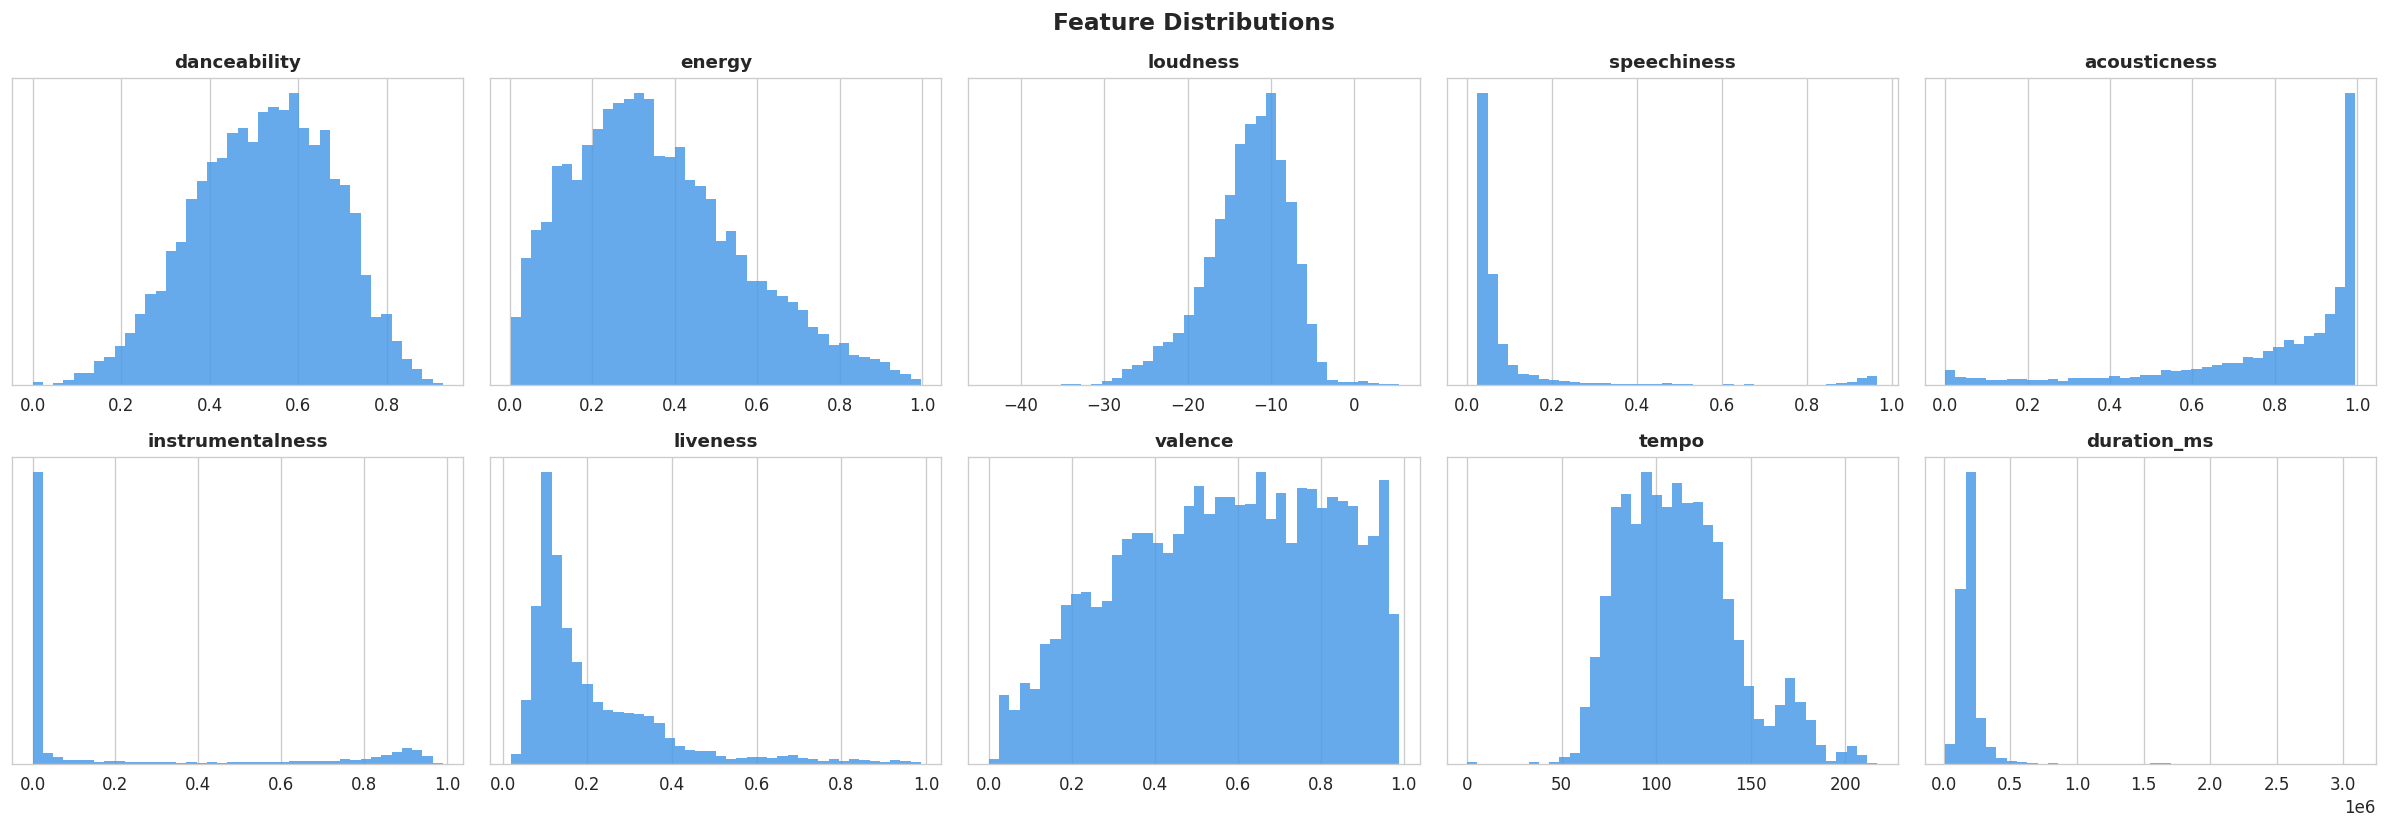

In [7]:
import os
os.makedirs('outputs', exist_ok=True)

# Feature Distributions
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
axes = axes.flatten()
for i, col in enumerate(features):
    axes[i].hist(X[col], bins=40, color='#4C9BE8', edgecolor='none', alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_yticks([])
for j in range(len(features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/01_feature_distributions.png', dpi=150)
plt.show()

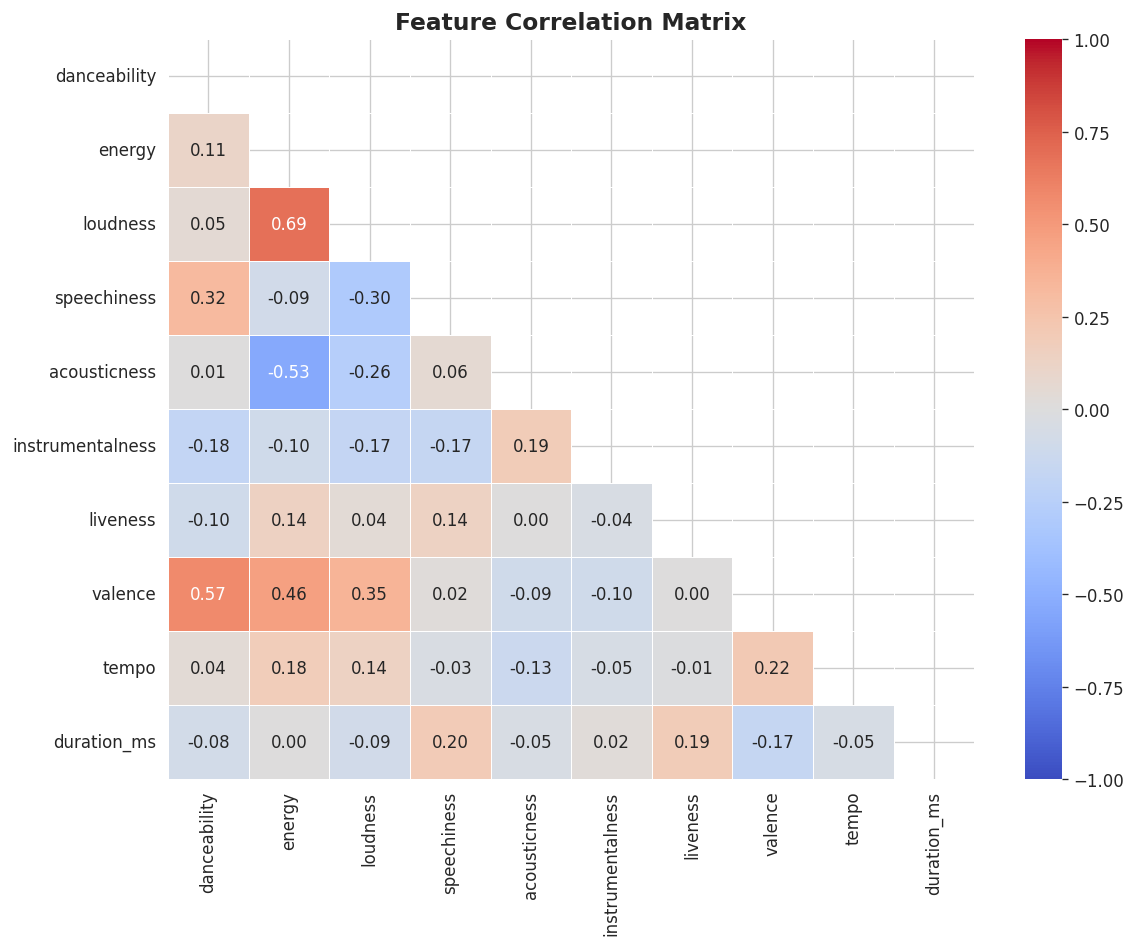

In [8]:
import os
os.makedirs('outputs', exist_ok=True)

# Correlation Heatmap
plt.figure(figsize=(10, 8))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/02_correlation_heatmap.png', dpi=150)
plt.show()

In [9]:
# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Scaling complete. Mean ≈ 0, Std ≈ 1 for all features.')
print(pd.DataFrame(X_scaled, columns=features).describe().round(3))

Scaling complete. Mean ≈ 0, Std ≈ 1 for all features.
       danceability     energy   loudness  speechiness  acousticness  \
count     10249.000  10249.000  10249.000    10249.000     10249.000   
mean          0.000      0.000      0.000        0.000        -0.000   
std           1.000      1.000      1.000        1.000         1.000   
min          -3.365     -1.738     -6.120       -0.582        -3.086   
25%          -0.717     -0.755     -0.569       -0.400        -0.383   
50%           0.056     -0.139      0.134       -0.348         0.393   
75%           0.752      0.618      0.688       -0.184         0.755   
max           2.608      3.124      3.613        4.282         0.838   

       instrumentalness   liveness    valence      tempo  duration_ms  
count         10249.000  10249.000  10249.000  10249.000    10249.000  
mean              0.000     -0.000      0.000      0.000        0.000  
std               1.000      1.000      1.000      1.000        1.000  
min      

## 3. Dimensionality Reduction (PCA)

PC1 explains 25.13% of variance
PC2 explains 16.08% of variance
Total: 41.21%


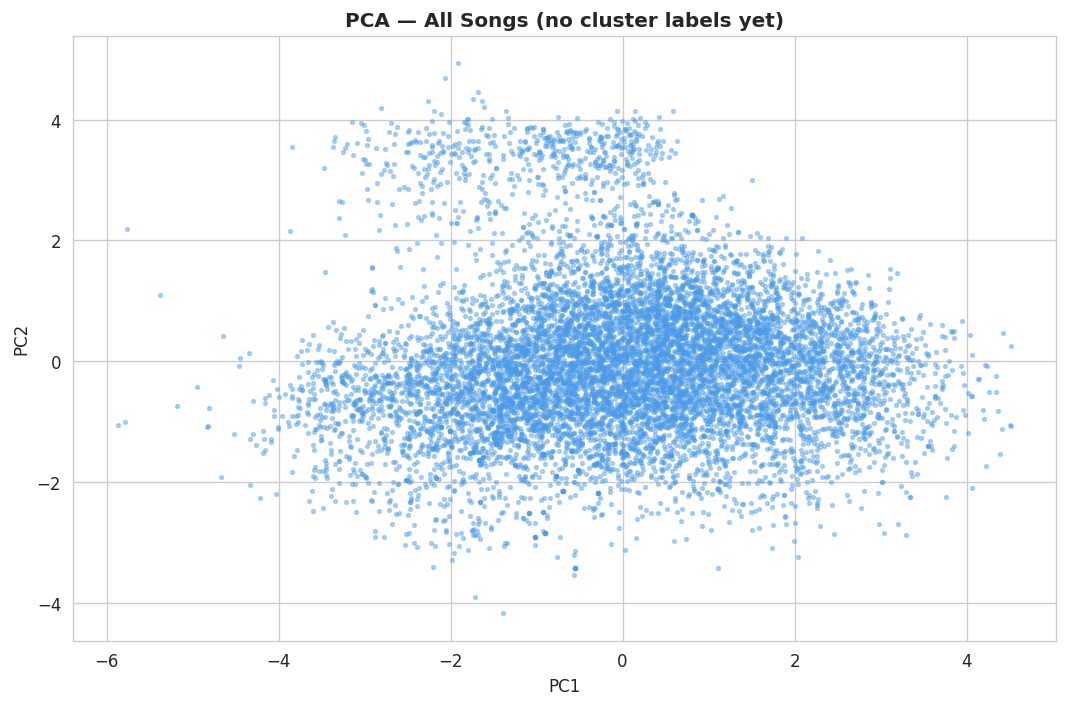

In [10]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

ev = pca.explained_variance_ratio_
print(f'PC1 explains {ev[0]:.2%} of variance')
print(f'PC2 explains {ev[1]:.2%} of variance')
print(f'Total: {sum(ev):.2%}')

# PCA scatter (unlabelled)
plt.figure(figsize=(9, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], s=5, alpha=0.4, color='#4C9BE8')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA — All Songs (no cluster labels yet)', fontweight='bold')
plt.tight_layout()
plt.show()

## 4. Find Optimal K (Elbow + Silhouette)

  k= 2  inertia=85,707  silhouette=0.1603
  k= 3  inertia=74,730  silhouette=0.1863
  k= 4  inertia=67,204  silhouette=0.1581
  k= 5  inertia=60,555  silhouette=0.1650
  k= 6  inertia=55,764  silhouette=0.1668
  k= 7  inertia=51,689  silhouette=0.1740
  k= 8  inertia=48,497  silhouette=0.1780
  k= 9  inertia=45,818  silhouette=0.1658
  k=10  inertia=43,416  silhouette=0.1689


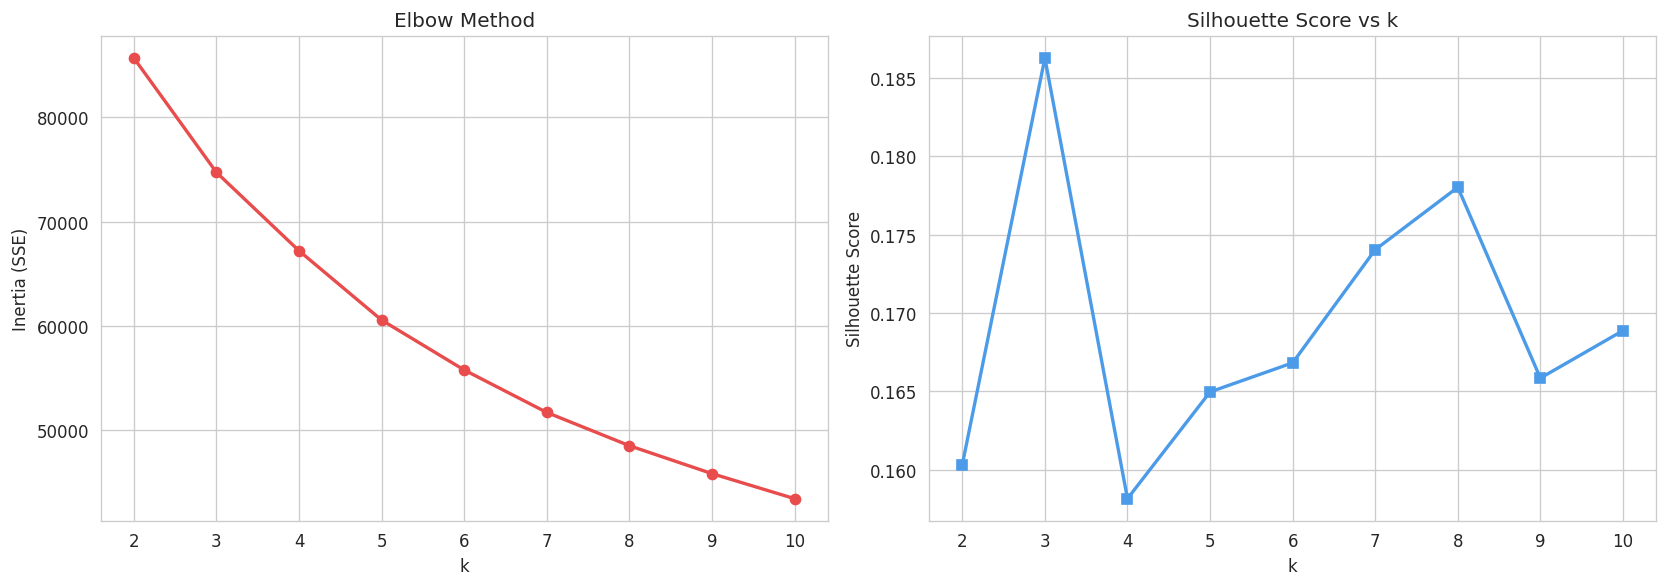


→ Best k by silhouette score: 3


In [11]:
import os
os.makedirs('outputs', exist_ok=True)

K_RANGE = range(2, 11)
inertias, sil_scores = [], []
rng = np.random.RandomState(42)

for k in K_RANGE:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    # FIX: silhouette_score has no sample_size param; subsample manually
    n_sample = min(5000, X_scaled.shape[0])
    idx = rng.choice(X_scaled.shape[0], size=n_sample, replace=False)
    sil_scores.append(silhouette_score(X_scaled[idx], labels[idx]))
    print(f'  k={k:2d}  inertia={km.inertia_:,.0f}  silhouette={sil_scores[-1]:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(list(K_RANGE), inertias, 'o-', color='#E84C4C', linewidth=2)
axes[0].set(xlabel='k', ylabel='Inertia (SSE)', title='Elbow Method')
axes[0].set_xticks(list(K_RANGE))

axes[1].plot(list(K_RANGE), sil_scores, 's-', color='#4C9BE8', linewidth=2)
axes[1].set(xlabel='k', ylabel='Silhouette Score', title='Silhouette Score vs k')
axes[1].set_xticks(list(K_RANGE))

plt.tight_layout()
plt.savefig('outputs/03_elbow_silhouette.png', dpi=150)
plt.show()

BEST_K = list(K_RANGE)[np.argmax(sil_scores)]
print(f'\n→ Best k by silhouette score: {BEST_K}')


## 5. K-Means Clustering

In [12]:
km = KMeans(n_clusters=BEST_K, random_state=42, n_init=10)
km_labels = km.fit_predict(X_scaled)

# FIX: silhouette_score has no sample_size param; subsample manually
rng = np.random.RandomState(42)
n_sample = min(5000, X_scaled.shape[0])
idx = rng.choice(X_scaled.shape[0], size=n_sample, replace=False)
km_sil = silhouette_score(X_scaled[idx], km_labels[idx])
km_dbi = davies_bouldin_score(X_scaled, km_labels)
print(f'Silhouette Score   : {km_sil:.4f}')
print(f'Davies-Bouldin     : {km_dbi:.4f}')
print(f'Inertia            : {km.inertia_:,.0f}')


Silhouette Score   : 0.1832
Davies-Bouldin     : 1.6942
Inertia            : 74,730


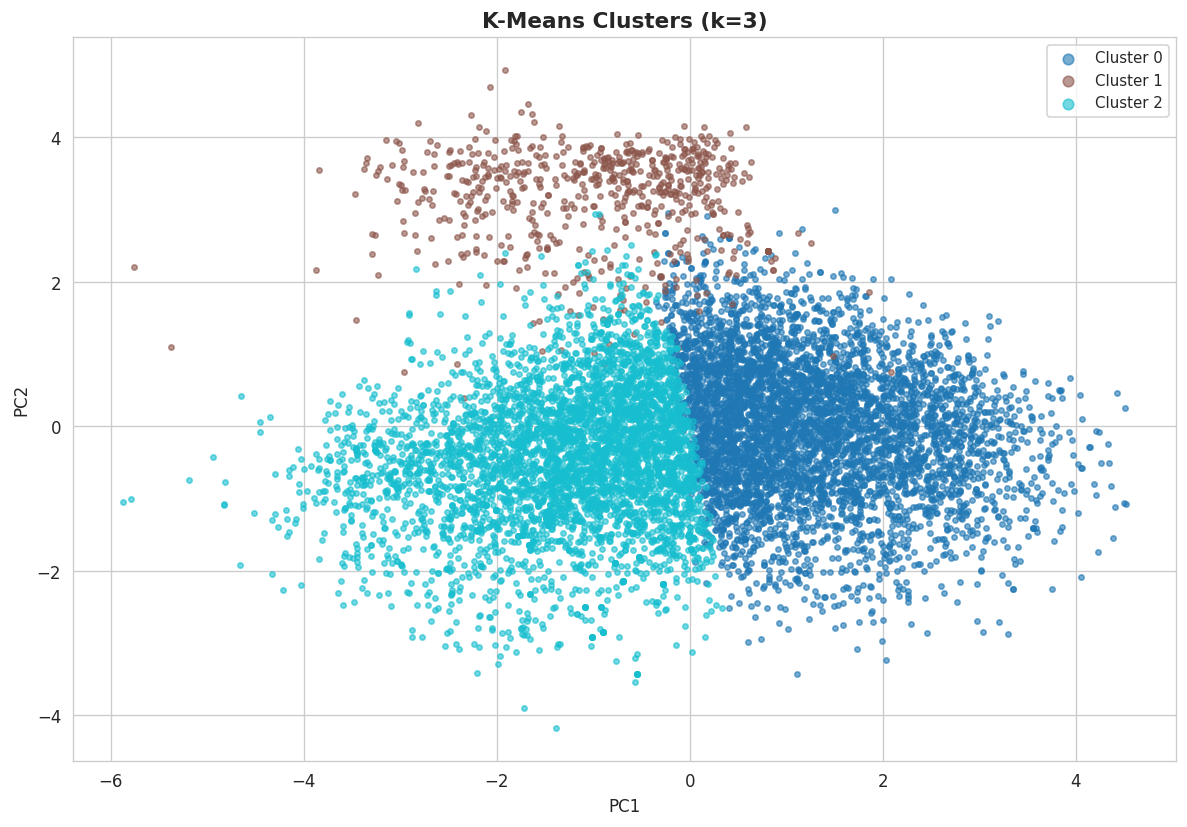

In [13]:
import os
os.makedirs('outputs', exist_ok=True)

# PCA scatter — K-Means
# FIX: cm.get_cmap is deprecated; use matplotlib.colormaps instead
import matplotlib
palette = matplotlib.colormaps['tab10'].resampled(BEST_K)
plt.figure(figsize=(10, 7))
for i in range(BEST_K):
    mask = km_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6,
                color=palette(i), label=f'Cluster {i}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'K-Means Clusters (k={BEST_K})', fontsize=13, fontweight='bold')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/09_kmeans_pca.png', dpi=150)
plt.show()


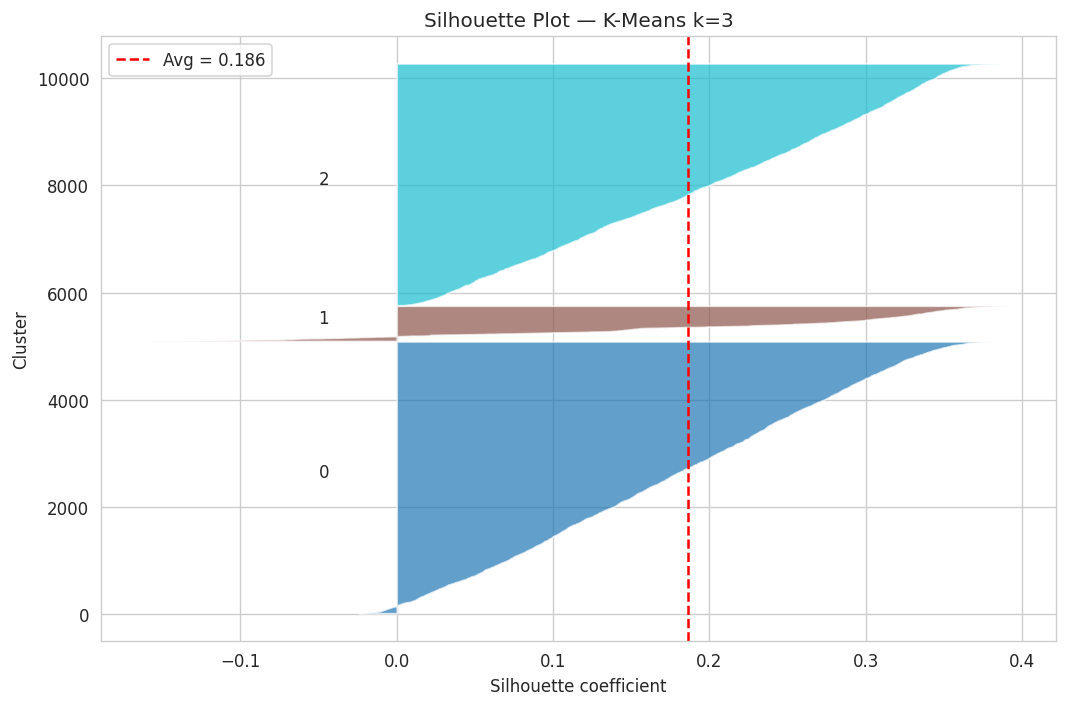

In [14]:
import os
os.makedirs('outputs', exist_ok=True)

# Silhouette plot
sil_vals = silhouette_samples(X_scaled, km_labels)
y_lower  = 10
fig, ax  = plt.subplots(figsize=(9, 6))
for i in range(BEST_K):
    ith = np.sort(sil_vals[km_labels == i])
    y_upper = y_lower + ith.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, ith,
                     facecolor=palette(i), alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * ith.shape[0], str(i))
    y_lower = y_upper + 10
ax.axvline(sil_vals.mean(), color='red', linestyle='--',
           label=f'Avg = {sil_vals.mean():.3f}')
ax.set(xlabel='Silhouette coefficient', ylabel='Cluster',
       title=f'Silhouette Plot — K-Means k={BEST_K}')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/08_kmeans_silhouette_plot.png', dpi=150)
plt.show()

In [15]:
# Cluster profile heatmap
# FIX: reset_index so positional km_labels aligns with X rows after dropna
X_prof = X.reset_index(drop=True).copy()
X_prof['cluster'] = km_labels
km_profile = X_prof.groupby('cluster')[features].mean()
print('Cluster Feature Means:')
km_profile.round(3)


Cluster Feature Means:


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
cluster,,,,,,,,,,
0,0.574,0.498,-9.970,0.075,0.683,0.153,0.221,0.727,120.787,187358.280
1,0.672,0.269,-18.988,0.816,0.815,0.013,0.301,0.524,104.748,325218.539
2,0.442,0.213,-15.275,0.059,0.891,0.332,0.197,0.401,103.642,201261.556


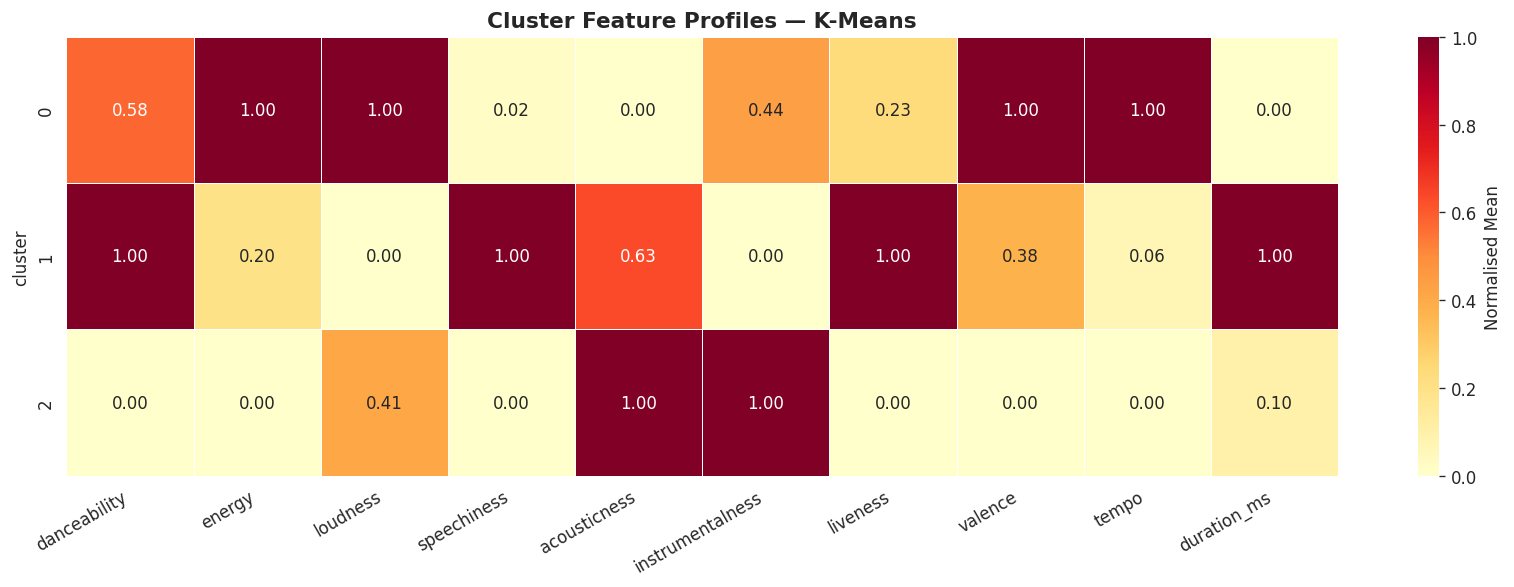

In [16]:
import os
os.makedirs('outputs', exist_ok=True)

normed = (km_profile - km_profile.min()) / (km_profile.max() - km_profile.min() + 1e-9)
plt.figure(figsize=(14, 5))
sns.heatmap(normed, annot=True, fmt='.2f', cmap='YlOrRd',
            linewidths=0.4, cbar_kws={'label': 'Normalised Mean'})
plt.title('Cluster Feature Profiles — K-Means', fontsize=13, fontweight='bold')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('outputs/05_kmeans_cluster_heatmap.png', dpi=150)
plt.show()

## 6. DBSCAN Clustering

In [17]:
db = DBSCAN(eps=1.5, min_samples=5)
db_labels = db.fit_predict(X_scaled)

n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
n_noise    = (db_labels == -1).sum()
print(f'Clusters found : {n_clusters}')
print(f'Noise points   : {n_noise}')

# FIX: guard db_sil so it's always defined; avoids NameError in summary cell
db_sil = None
if n_clusters > 1:
    non_noise = db_labels != -1
    rng = np.random.RandomState(42)
    n_sample = min(5000, non_noise.sum())
    # FIX: sample_size not valid; subsample manually
    pool = np.where(non_noise)[0]
    idx = rng.choice(pool, size=n_sample, replace=False)
    db_sil = silhouette_score(X_scaled[idx], db_labels[idx])
    print(f'Silhouette     : {db_sil:.4f}')
else:
    print('Silhouette     : N/A (need > 1 cluster)')


Clusters found : 13
Noise points   : 490
Silhouette     : -0.0892


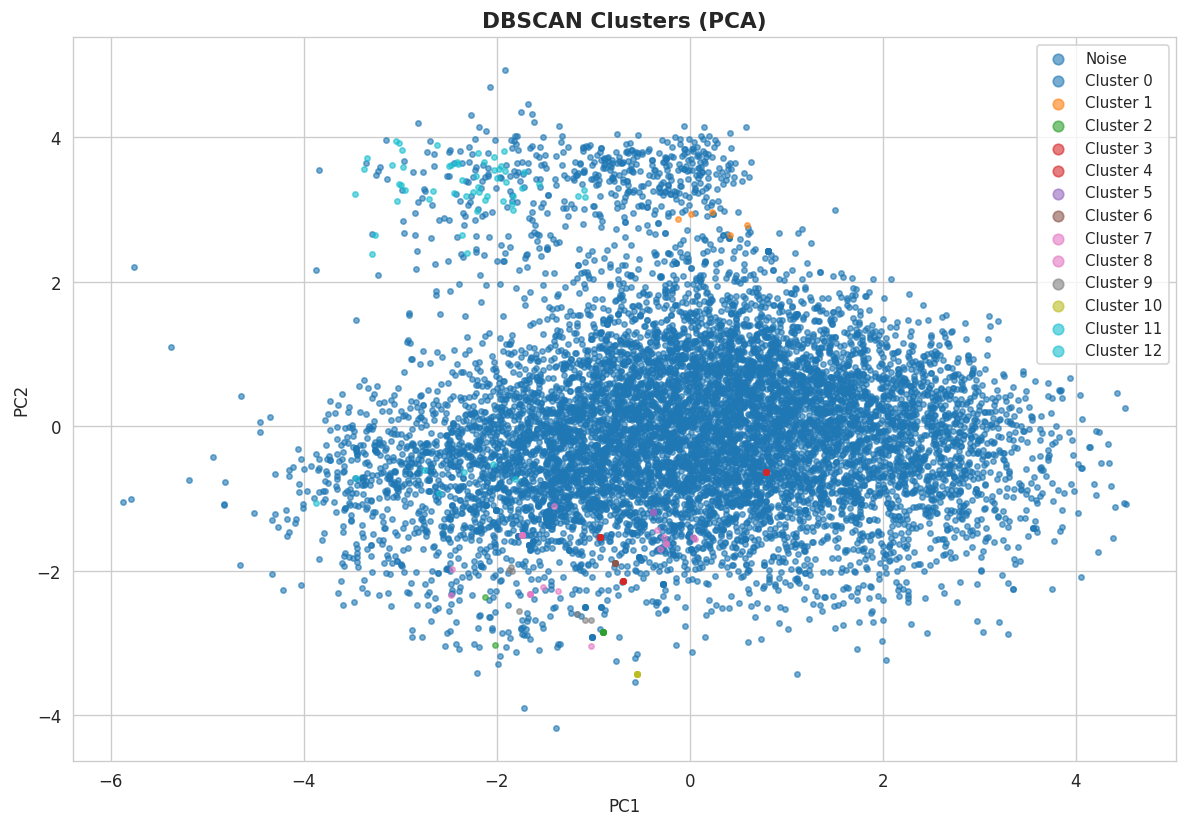

In [18]:
import os
os.makedirs('outputs', exist_ok=True)

unique_db = sorted(set(db_labels))
# FIX: cm.get_cmap is deprecated; use matplotlib.colormaps instead
import matplotlib
colors_db = matplotlib.colormaps['tab10'].resampled(len(unique_db))
plt.figure(figsize=(10, 7))
for i, lbl in enumerate(unique_db):
    mask = db_labels == lbl
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6,
                color=colors_db(i), label='Noise' if lbl == -1 else f'Cluster {lbl}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title('DBSCAN Clusters (PCA)', fontsize=13, fontweight='bold')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/10_dbscan_pca.png', dpi=150)
plt.show()


## 7. Hierarchical Clustering

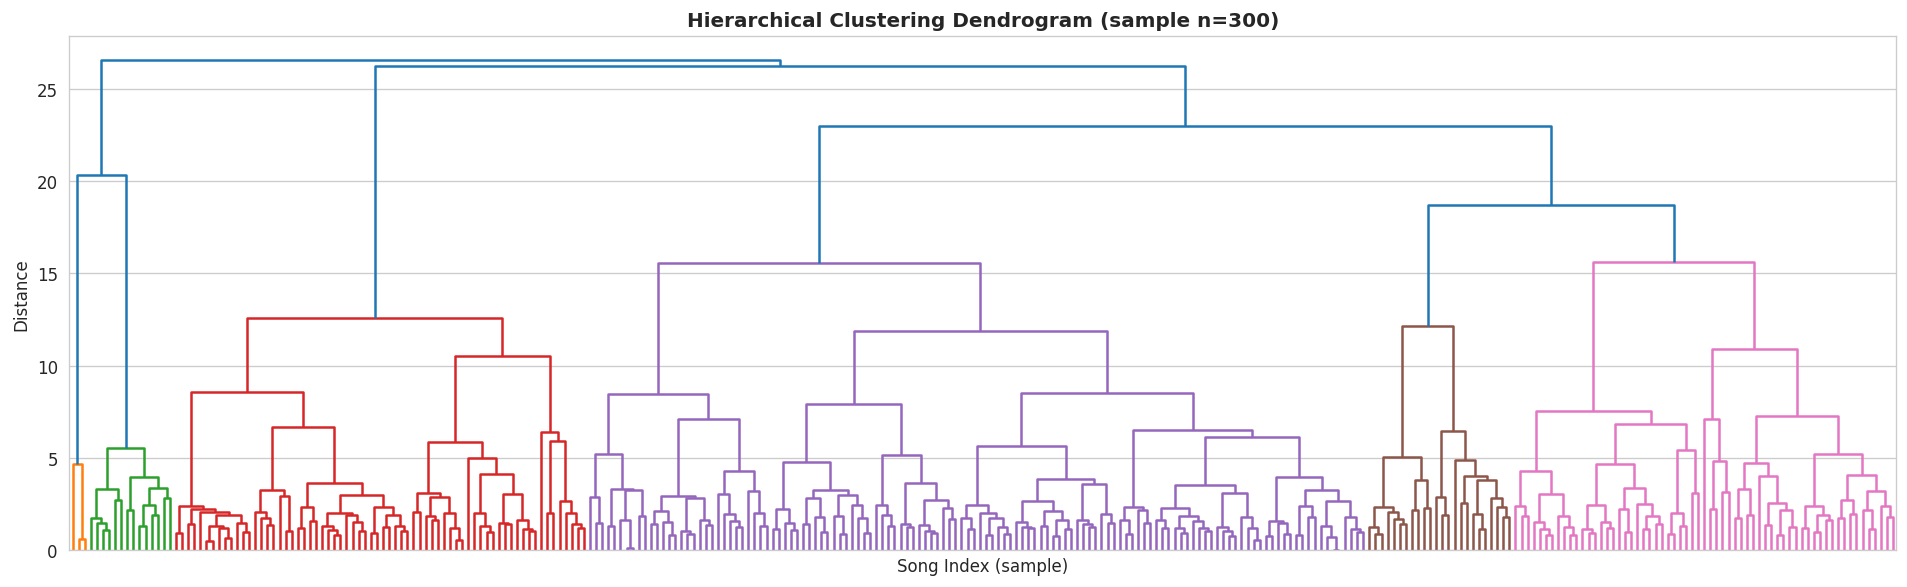

In [19]:
import os
os.makedirs('outputs', exist_ok=True)

# Dendrogram on a sample
sample_idx = np.random.RandomState(42).choice(X_scaled.shape[0],
                                               size=min(300, X_scaled.shape[0]), replace=False)
Z = linkage(X_scaled[sample_idx], method='ward')
plt.figure(figsize=(16, 5))
dendrogram(Z, no_labels=True, color_threshold=0.7 * max(Z[:, 2]))
plt.title('Hierarchical Clustering Dendrogram (sample n=300)', fontweight='bold')
plt.xlabel('Song Index (sample)')
plt.ylabel('Distance')
plt.tight_layout()
plt.savefig('outputs/04_dendrogram.png', dpi=150)
plt.show()

In [20]:
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler

# FIX: Recompute BEST_K and X_scaled if kernel was reset or cells run out of order
if 'BEST_K' not in vars() and 'BEST_K' not in globals():
    import pandas as pd
    _FEATURES = ['danceability','energy','loudness','speechiness',
                 'acousticness','instrumentalness','liveness',
                 'valence','tempo','duration_ms']
    _df = pd.read_csv('single_genre_artists.csv').drop_duplicates()
    _features = [f for f in _FEATURES if f in _df.columns]
    _X = _df[_features].dropna()
    _scaler = StandardScaler()
    X_scaled = _scaler.fit_transform(_X)
    _rng = np.random.RandomState(42)
    _sils = []
    for _k in range(2, 11):
        _lbl = KMeans(n_clusters=_k, random_state=42, n_init=10).fit_predict(X_scaled)
        _idx = _rng.choice(len(_lbl), size=min(5000, len(_lbl)), replace=False)
        _sils.append(silhouette_score(X_scaled[_idx], _lbl[_idx]))
    BEST_K = list(range(2, 11))[np.argmax(_sils)]
    print(f'BEST_K recomputed: {BEST_K}')

agg = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward')
hc_labels = agg.fit_predict(X_scaled)

# FIX: silhouette_score has no sample_size param; subsample manually
rng = np.random.RandomState(42)
n_sample = min(5000, X_scaled.shape[0])
idx = rng.choice(X_scaled.shape[0], size=n_sample, replace=False)
hc_sil = silhouette_score(X_scaled[idx], hc_labels[idx])
hc_dbi = davies_bouldin_score(X_scaled, hc_labels)
print(f'Silhouette   : {hc_sil:.4f}')
print(f'Davies-Bouldin: {hc_dbi:.4f}')


Silhouette   : 0.1586
Davies-Bouldin: 1.7147


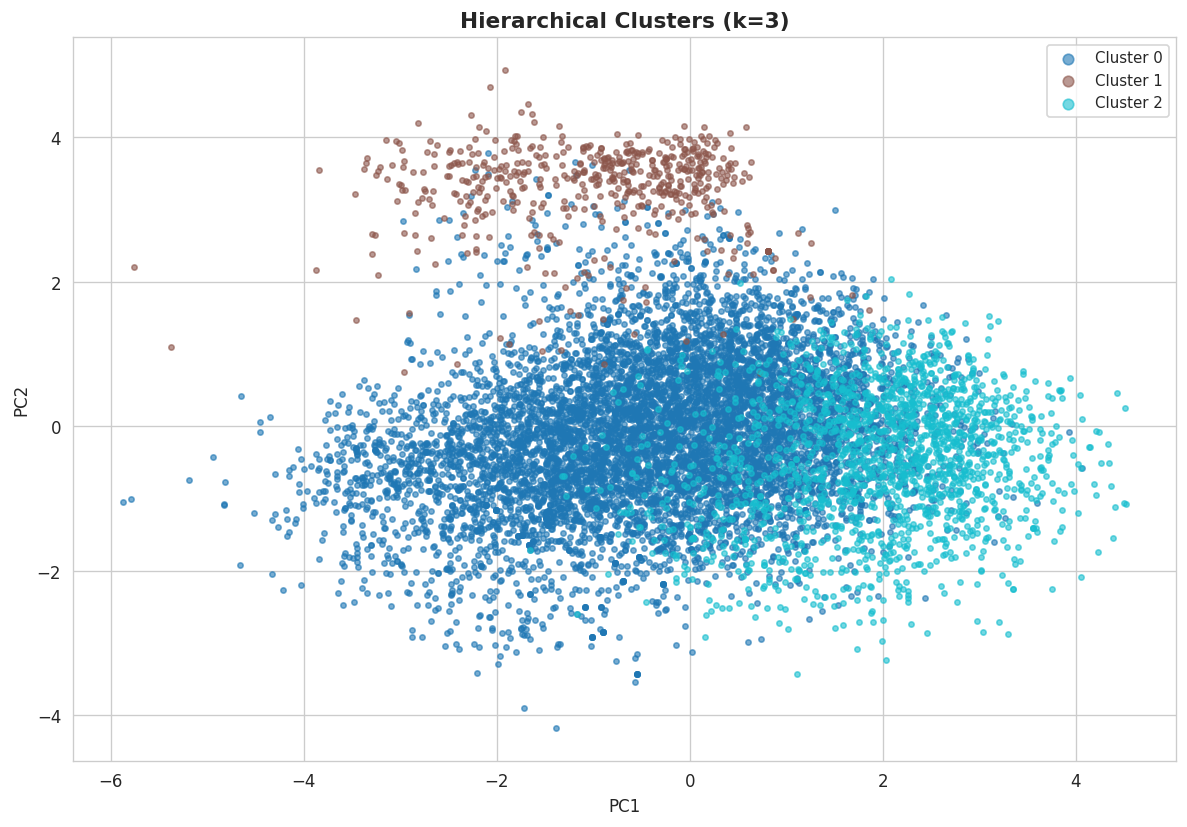

In [21]:
import os
os.makedirs('outputs', exist_ok=True)

import matplotlib
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# FIX: Recompute dependencies if kernel was reset or cells run out of order
if 'BEST_K' not in dir() and 'BEST_K' not in vars():
    import pandas as pd
    _df = pd.read_csv('single_genre_artists.csv').drop_duplicates()
    _FEATURES = ['danceability','energy','loudness','speechiness',
                 'acousticness','instrumentalness','liveness',
                 'valence','tempo','duration_ms']
    _features = [f for f in _FEATURES if f in _df.columns]
    _X = _df[_features].dropna()
    _scaler = StandardScaler()
    _Xs = _scaler.fit_transform(_X)
    _rng = np.random.RandomState(42)
    _sils = []
    for _k in range(2, 11):
        _lbl = KMeans(n_clusters=_k, random_state=42, n_init=10).fit_predict(_Xs)
        _idx = _rng.choice(len(_lbl), size=min(5000, len(_lbl)), replace=False)
        _sils.append(silhouette_score(_Xs[_idx], _lbl[_idx]))
    BEST_K = list(range(2, 11))[np.argmax(_sils)]
    X_scaled = _Xs
    print(f'BEST_K recomputed: {BEST_K}')

if 'hc_labels' not in dir() and 'hc_labels' not in vars():
    hc_labels = AgglomerativeClustering(n_clusters=BEST_K, linkage='ward').fit_predict(X_scaled)
    print('hc_labels recomputed')

if 'X_pca' not in dir() and 'X_pca' not in vars():
    from sklearn.decomposition import PCA
    X_pca = PCA(n_components=2, random_state=42).fit_transform(X_scaled)
    print('X_pca recomputed')

hc_palette = matplotlib.colormaps['tab10'].resampled(BEST_K)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
for i in range(BEST_K):
    mask = hc_labels == i
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], s=10, alpha=0.6,
                color=hc_palette(i), label=f'Cluster {i}')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.title(f'Hierarchical Clusters (k={BEST_K})', fontsize=13, fontweight='bold')
plt.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.savefig('outputs/11_hierarchical_pca.png', dpi=150)
plt.show()


## 8. Evaluation Summary

In [22]:
# FIX: db_sil is None when DBSCAN finds ≤1 cluster; guard round() call
summary = pd.DataFrame([
    {'Algorithm': 'K-Means',      'k': BEST_K,      'Silhouette': round(km_sil, 4),                              'Davies-Bouldin': round(km_dbi, 4)},
    {'Algorithm': 'DBSCAN',       'k': n_clusters,  'Silhouette': round(db_sil, 4) if db_sil is not None else 'N/A', 'Davies-Bouldin': 'N/A'},
    {'Algorithm': 'Hierarchical', 'k': BEST_K,      'Silhouette': round(hc_sil, 4),                              'Davies-Bouldin': round(hc_dbi, 4)},
])
print('\nEvaluation Summary')
summary



Evaluation Summary


,Algorithm,k,Silhouette,Davies-Bouldin
0,K-Means,3,0.1832,1.6942
1,DBSCAN,13,-0.0892,N/A
2,Hierarchical,3,0.1586,1.7147


## 9. Mood / Genre Inference

In [23]:
MOOD_RULES = {
    'Party / Upbeat'      : lambda r: r['energy'] > 0.7 and r['danceability'] > 0.65,
    'Chill / Acoustic'    : lambda r: r['acousticness'] > 0.6 and r['energy'] < 0.5,
    'Electronic / Dance'  : lambda r: r['instrumentalness'] > 0.5 and r['tempo'] > 120,
    'Ambient / Mellow'    : lambda r: r['energy'] < 0.35 and r['valence'] < 0.4,
    'Intense / Rock-like' : lambda r: r['loudness'] > -5 and r['energy'] > 0.8,
}

def infer_mood(row):
    for mood, rule in MOOD_RULES.items():
        try:
            if rule(row): return mood
        except KeyError:
            pass
    return 'Mixed / Other'

mood_map = {i: infer_mood(km_profile.loc[i]) for i in km_profile.index}
print('Cluster → Mood Labels:')
for cid, mood in mood_map.items():
    n = (km_labels == cid).sum()
    print(f'  Cluster {cid:2d} ({n:5d} songs) → {mood}')

Cluster → Mood Labels:
  Cluster  0 ( 5076 songs) → Chill / Acoustic
  Cluster  1 (  657 songs) → Chill / Acoustic
  Cluster  2 ( 4516 songs) → Chill / Acoustic


## 10. Export Final CSV

In [24]:
df_out = X.copy()
if not meta.empty:
    for col in meta.columns:
        df_out[col] = meta[col].values
df_out['kmeans_cluster']       = km_labels
df_out['hierarchical_cluster'] = hc_labels
df_out['dbscan_cluster']       = db_labels
df_out['kmeans_mood']          = df_out['kmeans_cluster'].map(mood_map)

df_out.to_csv('outputs/clustered_songs.csv', index=False)
print(f'Saved → outputs/clustered_songs.csv  ({len(df_out)} rows)')
df_out.head()

Saved → outputs/clustered_songs.csv  (10249 rows)


,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,kmeans_cluster,hierarchical_cluster,dbscan_cluster,kmeans_mood
0,0.563,0.184,-13.757,0.0512,0.993,0.000016,0.325,0.654,133.088,161427.0,2,0,0,Chill / Acoustic
1,0.427,0.180,-15.375,0.0670,0.989,0.000000,0.128,0.431,78.459,223440.0,2,0,0,Chill / Acoustic
2,0.511,0.206,-15.514,0.0592,0.995,0.000000,0.418,0.481,70.443,208267.0,2,0,0,Chill / Acoustic
3,0.676,0.467,-12.393,0.1650,0.991,0.000000,0.219,0.726,129.775,161933.0,0,0,0,Chill / Acoustic
4,0.650,0.298,-13.806,0.1380,0.991,0.000000,0.373,0.844,75.950,167973.0,0,0,0,Chill / Acoustic


---
## ✅ Project Complete
All outputs saved to `./outputs/`. Refer to `README.md` for interpretation guidance.

## 11. Showcase Results with Streamlit

### Troubleshooting `localtunnel` (Optional: Use ngrok for more stability)

If you encounter issues with `localtunnel` (like assets not loading or connection drops), `ngrok` is often a more stable alternative for exposing your Streamlit app from Colab.

To use `ngrok`, you'll need an authtoken. You can get one for free by signing up at [ngrok.com](https://ngrok.com/signup). Once you have your authtoken, add it to Colab's secrets manager (under the '🔑' icon in the left panel) with the name `NGROK_AUTH_TOKEN`.

In [36]:
import sys

# Check if running in Colab and install streamlit if not already installed
if 'google.colab' in sys.modules:
    !pip install streamlit -q

In [37]:
%%writefile streamlit_app.py

import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the clustered data
try:
    df = pd.read_csv('outputs/clustered_songs.csv')
except FileNotFoundError:
    st.error("Error: 'clustered_songs.csv' not found. Please ensure the clustering steps are run and the file is generated.")
    st.stop()

st.set_page_config(layout='wide')
st.title('🎵 Amazon Music Clustering Results')
st.write('---')

st.header('Clustering Overview')
st.write("This application showcases the results of clustering Amazon Music songs based on their audio features.")

if not df.empty:
    st.subheader('Original Data Sample')
    st.dataframe(df.head())

    st.subheader('K-Means Cluster Distribution')
    kmeans_counts = df['kmeans_cluster'].value_counts().sort_index()
    fig1, ax1 = plt.subplots(figsize=(8, 5))
    sns.barplot(x=kmeans_counts.index, y=kmeans_counts.values, palette='viridis', ax=ax1)
    ax1.set_title('K-Means Cluster Sizes')
    ax1.set_xlabel('Cluster')
    ax1.set_ylabel('Number of Songs')
    st.pyplot(fig1)

    st.subheader('K-Means Cluster Feature Profiles')
    km_profile = df.groupby('kmeans_cluster')[['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms']].mean()
    normed_km_profile = (km_profile - km_profile.min()) / (km_profile.max() - km_profile.min() + 1e-9)

    fig2, ax2 = plt.subplots(figsize=(12, 6))
    sns.heatmap(normed_km_profile, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.4, cbar_kws={'label': 'Normalised Mean'}, ax=ax2)
    ax2.set_title('K-Means Cluster Feature Profiles (Normalised)')
    ax2.tick_params(axis='x', rotation=30)
    st.pyplot(fig2)

    st.subheader('Mood Inference per K-Means Cluster')
    mood_map = df[['kmeans_cluster', 'kmeans_mood']].drop_duplicates().set_index('kmeans_cluster')['kmeans_mood']
    st.write(mood_map)

    st.write('---')
    st.header('Individual Song Search')
    song_name = st.text_input('Enter a song name to find its cluster and mood:', '')

    if song_name:
        search_results = df[df['name_song'].str.contains(song_name, case=False, na=False)]
        if not search_results.empty:
            st.subheader(f'Results for "{song_name}"')
            st.dataframe(search_results[['name_song', 'name_artists', 'kmeans_cluster', 'kmeans_mood']].head())
        else:
            st.write('No songs found matching your query.')
else:
    st.write("No data available to display. Please run the notebook cells to generate the clustered data.")

Overwriting streamlit_app.py


In [38]:
# Install ngrok
!pip install pyngrok -q

# Kill any processes using port 8501 (Streamlit's default)
!fuser -k 8501/tcp

# Kill any running ngrok processes from previous runs
!killall ngrok

ngrok: no process found


In [40]:
import os
from pyngrok import ngrok, conf
from google.colab import userdata

# Get ngrok authtoken from Colab secrets
NGROK_AUTH_TOKEN = userdata.get('NGROK_AUTH_TOKEN')

if NGROK_AUTH_TOKEN:
    # Set ngrok authtoken
    conf.get_default().auth_token = NGROK_AUTH_TOKEN

    # Connect to ngrok
    ngrok_tunnel = ngrok.connect(8501)
    print(f'Your Streamlit app is accessible via ngrok at: {ngrok_tunnel.public_url}')
    print('Click the URL above to open your app in a new tab.')

    # Start Streamlit app in the background
    os.system('streamlit run streamlit_app.py &>/dev/null&')
else:
    print("NGROK_AUTH_TOKEN not found in Colab secrets. Please add it to use ngrok.")

SecretNotFoundError: Secret NGROK_AUTH_TOKEN does not exist.